In [1]:
%load_ext autoreload
%autoreload 2
# !hostname
# !pwd
import os, sys
# print(sys.executable)
# os.environ['CUDA_VISIBLE_DEVICES'] = "7"
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = "false"
# sys.path.append(os.path.abspath(".."))

In [2]:
import os, sys, glob, pickle, copy, time
from functools import partial

import numpy as np
import pandas as pd
# import xarray as xr
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = (15, 5)
import seaborn as sns
sns.set_theme()

from tqdm.auto import tqdm
from einops import rearrange, reduce, repeat
# from einop import einop

import jax
import jax.numpy as jnp
from jax.random import split

import flax
import flax.linen as nn
from flax.training.train_state import TrainState

import optax

import experiment_utils
from main import *
import plotstyle
plotstyle.set_plot_style()

In [3]:
from models.mae import GPTConfig, MAEConfig, MAE

In [21]:
cfg = MAEConfig(tensor_shape=(4, 32, 32), patch_shape=(1, 4, 4), mask_ratio=0.25)
cfg.enc.n_embd = 128
cfg.dec.n_embd = 64
print(cfg)
mae = MAE(cfg)

MAEConfig(tensor_shape=(4, 32, 32), patch_shape=(1, 4, 4), mask_ratio=0.25, enc=GPTConfig(n_layer=12, n_head=8, n_embd=128, dropout=0.0), dec=GPTConfig(n_layer=4, n_head=4, n_embd=64, dropout=0.0))


In [22]:
rng = jax.random.PRNGKey(0)
x = (jax.random.normal(rng, cfg.tensor_shape) < 0.).astype(jnp.float32)
print(x.shape)
params = mae.init(rng, rng, x)
outputs = mae.apply(params, rng, x)
jax.tree.map(lambda x: x.shape, outputs)

(4, 32, 32)
ctx_len: 256
patch_dim: 16
ctx_len: 256
patch_dim: 16


{'features': (12, 192, 128),
 'idx_keep': (192,),
 'idx_mask': (64,),
 'input_mask': (4, 32, 32),
 'logits': (4, 32, 32),
 'loss': (),
 'loss_ce': (4, 32, 32),
 'x_enc': (192, 128),
 'x_in': (4, 32, 32)}

In [23]:
outputs['loss']

Array(0.8948972, dtype=float32)

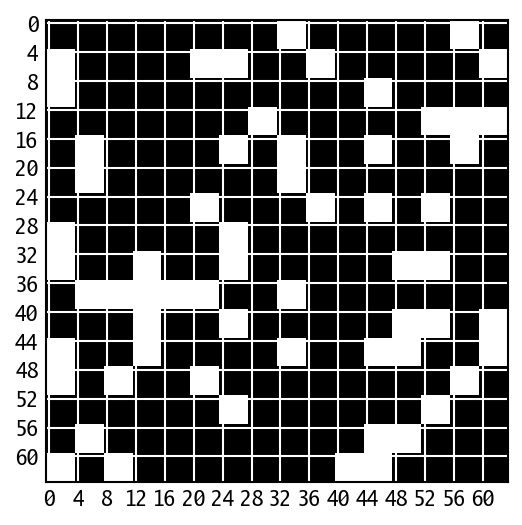

In [75]:
plt.imshow(outputs['input_mask'][0], cmap='gray', vmin=0, vmax=1)
plt.xticks(np.arange(0, 64, 4), np.arange(0, 64, 4))
plt.yticks(np.arange(0, 64, 4), np.arange(0, 64, 4))
plt.show()

In [76]:
jnp.sort(outputs['idx_mask'])

Array([   8,   14,   16,   21,   22,   25,   31,   32,   43,   55,   61,
         62,   63,   65,   70,   72,   75,   78,   81,   88,  101,  105,
        107,  109,  112,  118,  128,  131,  134,  140,  141,  145,  146,
        147,  148,  149,  152,  163,  166,  172,  173,  175,  176,  179,
        184,  187,  188,  191,  192,  194,  197,  206,  214,  221,  225,
        235,  236,  240,  242,  250,  251,  256,  259,  263,  264,  265,
        266,  267,  279,  283,  284,  289,  291,  294,  298,  302,  303,
        314,  324,  332,  335,  338,  340,  342,  348,  353,  354,  359,
        361,  365,  373,  388,  392,  393,  394,  395,  398,  403,  408,
        411,  418,  419,  432,  440,  442,  444,  445,  447,  448,  457,
        466,  467,  472,  475,  480,  482,  487,  488,  490,  501,  503,
        507,  508,  511,  513,  519,  520,  524,  525,  529,  531,  532,
        535,  537,  539,  540,  541,  544,  545,  549,  552,  557,  560,
        564,  567,  569,  571,  586,  593,  597,  6

In [4]:
from train_mae import Main, Args

In [37]:
args = Args()
args.data.grid_size = 64
args.data.dt = 32

seeds_all = list(range(1))
patch_size_all = [(1, 2, 2), (2, 4, 4), (4, 8, 8), (8, 16, 16)]

# for patch_size in patch_size_all:
#     a, b, _ = patch_size
#     ctx_len = (32//a)* (64//b) * (64//b)
#     patch_dim = a*b*b
#     print(ctx_len, patch_dim)

# for seed in seeds_all:
    # for mask_ratio in [0.01, 0.05, 0.1, 0.2, 0.5]:
for grid_size in [4, 8, 16, 32, 64]:
    dt = grid_size//2
    for patch_size in [2, 4, 8, 16]:
        if patch_size > grid_size:
            continue
        pt = patch_size // 2
        ctx_len = (dt//pt)* (grid_size//patch_size) * (grid_size//patch_size)
        patch_dim = pt*patch_size*patch_size
        if ctx_len > 4096:
            continue
        print(f"grid: {dt}x{grid_size}x{grid_size}")
        print(f"patch: {pt}x{patch_size}x{patch_size}")
        print(f"ctx_len: {ctx_len}, patch_dim: {patch_dim}")
        print()

grid: 2x4x4
patch: 1x2x2
ctx_len: 8, patch_dim: 4

grid: 2x4x4
patch: 2x4x4
ctx_len: 1, patch_dim: 32

grid: 4x8x8
patch: 1x2x2
ctx_len: 64, patch_dim: 4

grid: 4x8x8
patch: 2x4x4
ctx_len: 8, patch_dim: 32

grid: 4x8x8
patch: 4x8x8
ctx_len: 1, patch_dim: 256

grid: 8x16x16
patch: 1x2x2
ctx_len: 512, patch_dim: 4

grid: 8x16x16
patch: 2x4x4
ctx_len: 64, patch_dim: 32

grid: 8x16x16
patch: 4x8x8
ctx_len: 8, patch_dim: 256

grid: 8x16x16
patch: 8x16x16
ctx_len: 1, patch_dim: 2048

grid: 16x32x32
patch: 1x2x2
ctx_len: 4096, patch_dim: 4

grid: 16x32x32
patch: 2x4x4
ctx_len: 512, patch_dim: 32

grid: 16x32x32
patch: 4x8x8
ctx_len: 64, patch_dim: 256

grid: 16x32x32
patch: 8x16x16
ctx_len: 8, patch_dim: 2048

grid: 32x64x64
patch: 2x4x4
ctx_len: 4096, patch_dim: 32

grid: 32x64x64
patch: 4x8x8
ctx_len: 512, patch_dim: 256

grid: 32x64x64
patch: 8x16x16
ctx_len: 64, patch_dim: 2048



In [6]:
args

Args(seed=0, save_dir=None, n_iters=10000, log_every=1000, model=MAEConfig(dt=1, nt=4, nh=16, nw=16, pt=1, ph=4, pw=4, mask_ratio=0.1, enc=GPTConfig(n_layer=12, n_head=8, n_embd=64, dropout=0.0), dec=GPTConfig(n_layer=4, n_head=8, n_embd=32, dropout=0.0)), opt=OptimizerArgs(batch_size=32, learning_rate=0.0003, weight_decay=0.0, clip_grad_norm=1.0), data=DataArgs(gol_params=6152, grid_size=64, t_start=32, t_end=64))

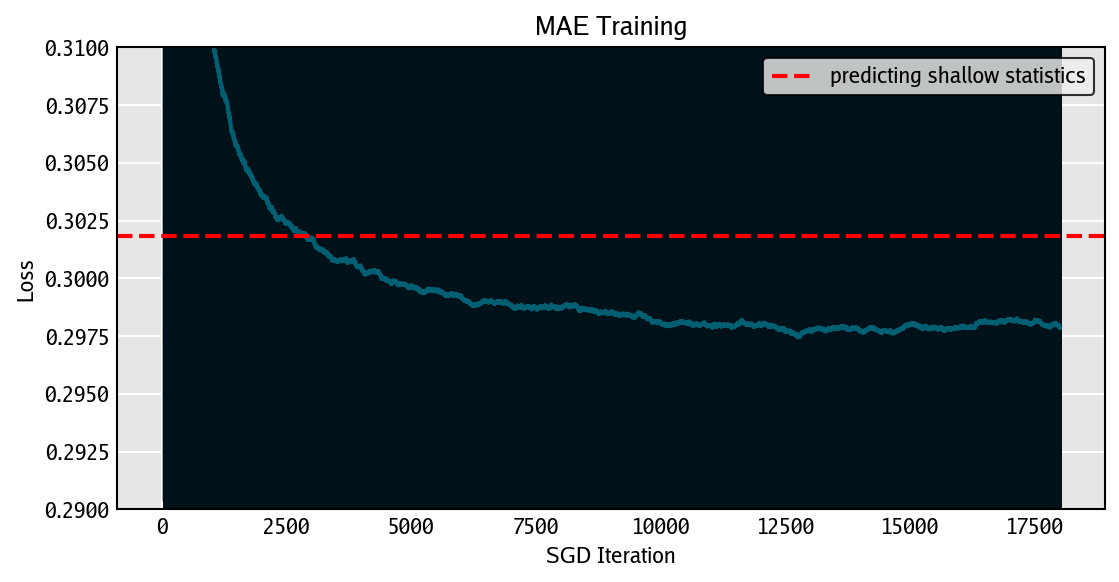

In [77]:
loss_history = main.loss_history
plt.plot(loss_history)
plt.plot(pd.DataFrame(loss_history).ewm(span=5000).mean())
plt.ylim(0.29, 0.31)

plt.axhline(0.30183737659076026, color='red', linestyle='--', label='predicting shallow statistics')
# plt.ylim(0, .35)
plt.legend()
plt.title("MAE Training")
plt.xlabel("SGD Iteration")
plt.ylabel("Loss")
plt.show()

In [49]:
p = []
for i in tqdm(range(100)):
    rng = jax.random.PRNGKey(i)
    batch = main.generate_instance(rng)
    p.append(batch['state'].mean().item())

100%|██████████| 100/100 [00:13<00:00,  7.56it/s]


In [50]:
p = np.mean(p)

In [51]:
p

np.float64(0.08969749450683594)

In [52]:
-p*np.log(p) - (1-p)*np.log(1-p)

np.float64(0.30183737659076026)